# 3. Data Augmentation & Data Generators
Tahap ini bertujuan untuk menyiapkan jalur data dari folder ke dalam model AI.
- **Data Latih (Train)**: Dikenakan augmentasi (rotasi, zoom, geser) untuk mencegah *overfitting* karena dataset tidak seimbang.
- **Data Validasi & Uji (Val & Test)**: Hanya dinormalisasi pikselnya (rescale 1./255) tanpa augmentasi, dengan `shuffle=False` pada data uji untuk evaluasi matriks yang akurat.

In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.pyplot as plt

# Path dataset
base_dir = '../dataset/processed'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

# 1. Data Augmentation untuk Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,  # Citra medis biasanya tidak boleh dibalik horizontal
    fill_mode='nearest'
)

# 2. Tanpa augmentasi untuk validation dan test
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# 3. Generator dataset
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),   # ukuran input ResNet50
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

print("ImageDataGenerator dan dataset generator berhasil dibuat!")

Found 10606 images belonging to 3 classes.
Found 2271 images belonging to 3 classes.
Found 2276 images belonging to 3 classes.
ImageDataGenerator dan dataset generator berhasil dibuat!


## Visualisasi Hasil Augmentasi
*(Bagian ini sangat penting untuk diekstrak gambarnya dan dimasukkan ke dalam draf Jurnal SINTA sebagai bukti penerapan Data Augmentation).*

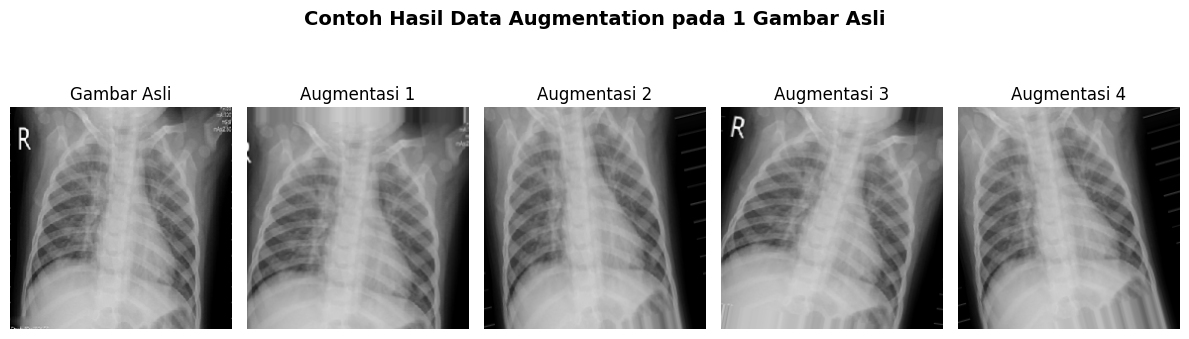

In [4]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Mengambil 1 contoh gambar Viral Pneumonia dari folder train
sample_folder = os.path.join(train_dir, 'Viral_Pneumonia')
sample_image_name = os.listdir(sample_folder)[0]
sample_image_path = os.path.join(sample_folder, sample_image_name)

img = image.load_img(sample_image_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

plt.figure(figsize=(12, 4))
plt.suptitle('Contoh Hasil Data Augmentation pada 1 Gambar Asli', fontsize=14, fontweight='bold')

plt.subplot(1, 5, 1)
plt.imshow(img, cmap='gray')
plt.title('Gambar Asli')
plt.axis('off')

# Hasilkan 4 gambar augmentasi secara acak dan tampilkan
i = 2
for batch in train_datagen.flow(x, batch_size=1):
    plt.subplot(1, 5, i)
    plt.imshow(batch[0], cmap='gray') 
    plt.title(f'Augmentasi {i-1}')
    plt.axis('off')
    i += 1
    if i > 5:
        break

plt.tight_layout()
plt.show()